# 04. Behavioral calibration

This notebook calibrates the reduced-form promotion-response model used in the policy analysis. The model separates the contemporaneous response to a promotion from the subsequent displacement of demand and represents persistence through a geometrically decaying state.

Calibration is based on fixed-effect-residualized promotion episodes from the designated calibration period. The parameters are selected to reproduce the observed promotion-week response and the post-promotion residual path. When persistence is only weakly informed by the data, uncertainty is represented through the pre-specified persistence grid rather than by reporting an artificially precise point estimate.

The calibrated parameters are decision-model inputs. They are not interpreted as causally identified structural parameters, and the latent displacement state is not treated as a direct measure of household inventory.

**Inputs:** Notebook 02 predictions and the saved selected panel. **Outputs:** pooled empirical-Bayes calibration draws and diagnostics consumed by Notebook 05.

## 1. Setup and calibration sample

This section loads the governed configuration, fixed panel selection, and
chronological calibration split, then constructs the cleaned empirical sample
used throughout the notebook.

In [1]:
# Imports and shared calibration helpers.

# Import scientific libraries, project utilities, and the shared calibration helpers.
from __future__ import annotations

from functools import partial
import json
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dynamic_promotion_planning.calibration import (
    alternating_multiway_residual,
    bootstrap_behavioral_moments,
    bootstrap_event_study_rows,
    canonical_promotion_indicator,
    first_existing_column,
    fit_persistence,
    isolated_promotion_mask,
    load_panel_selection,
)
from dynamic_promotion_planning.config import load_analysis_config
from dynamic_promotion_planning.paths import project_paths

warnings.filterwarnings("ignore", category=FutureWarning)

paths = project_paths()
analysis_config = load_analysis_config()
behavioral_config = analysis_config.behavioral

PROJECT_ROOT = paths.root
PROCESSED_DIR = paths.data_processed
TABLE_DIR = PROJECT_ROOT / 'results' / 'empirical_bayes' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'results' / 'empirical_bayes' / 'figures'
MODEL_DIR = PROJECT_ROOT / 'results' / 'empirical_bayes' / 'models'
for directory in (TABLE_DIR, FIGURE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)
DEMAND_ARTIFACT_DIR = paths.artifact_demand
CALIBRATION_ARTIFACT_DIR = paths.artifact_calibration

# Pre-specified calibration settings.

# Read all calibration choices from the governed project configuration rather than hard-coding them in the notebook.
DATA_PATH = PROCESSED_DIR / "cereal_demand_model_data.parquet"
PREDICTION_PATH = DEMAND_ARTIFACT_DIR / "demand_predictions.pkl"

PRIMARY_MODEL = behavioral_config.primary_model
EVENT_WINDOW = np.arange(
    -behavioral_config.event_pre_weeks,
    behavioral_config.event_post_weeks + 1,
    dtype=int,
)
PRE_EVENT_WEEKS = behavioral_config.pre_event_weeks
POST_LAGS_FOR_CALIBRATION = behavioral_config.post_lags_for_calibration

MIN_CALIBRATION_DISCOUNT = behavioral_config.minimum_calibration_discount

RANDOM_SEED = behavioral_config.random_seed
BOOTSTRAP_REPLICATIONS = behavioral_config.bootstrap_replications
EVENT_STUDY_CI = behavioral_config.event_study_interval

ELASTICITY_BOUNDS = behavioral_config.elasticity_bounds
PROMOTION_LIFT_BOUNDS = behavioral_config.promotion_lift_bounds
DISPLACEMENT_BOUNDS = behavioral_config.displacement_bounds
PERSISTENCE_BOUNDS = behavioral_config.persistence_bounds
MIN_PERSISTENCE_SIGNAL = behavioral_config.minimum_persistence_signal
MAX_PERSISTENCE_SLOPE_RATIO = (
    behavioral_config.maximum_persistence_slope_ratio
)
PERSISTENCE_PARTIAL_ID_GRID = (
    behavioral_config.persistence_partial_identification_grid
)

GROSS_MARGIN_COLUMN = behavioral_config.gross_margin_column
MIN_VALID_MARGIN = behavioral_config.minimum_valid_margin
MAX_VALID_MARGIN = behavioral_config.maximum_valid_margin

# Canonical input and output paths.

EB_CALIBRATION_DIR = CALIBRATION_ARTIFACT_DIR / 'empirical_bayes'
EB_CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)
PARAMETER_OUTPUT_PATH = EB_CALIBRATION_DIR / 'pooled_behavioral_draws.pkl'
BASE_PARAMETER_OUTPUT_PATH = EB_CALIBRATION_DIR / 'pooled_behavioral_bootstrap.pkl'
EVENT_OUTPUT_PATH = EB_CALIBRATION_DIR / 'isolated_promotion_events.pkl'
EVENT_STUDY_TABLE_PATH = TABLE_DIR / 'promotion_event_study.csv'
DEPTH_EVENT_STUDY_TABLE_PATH = TABLE_DIR / 'promotion_event_study_by_depth.csv'
MOMENT_TABLE_PATH = TABLE_DIR / 'pooled_calibration_moments.csv'
PARAMETER_SUMMARY_PATH = TABLE_DIR / 'pooled_behavioral_parameter_summary.csv'
CONFIGURATION_PATH = MODEL_DIR / 'behavioral_calibration.json'
EVENT_STUDY_FIGURE_PATH = FIGURE_DIR / 'promotion_event_study.png'
DEPTH_EVENT_STUDY_FIGURE_PATH = FIGURE_DIR / 'promotion_event_study_by_depth.png'


In [2]:
# Load the processed demand panel.

# Load the processed demand panel after checking that the required input artifact exists.
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Demand data not found: {DATA_PATH}")

history_raw = pd.read_parquet(DATA_PATH)

# Recover the fixed panel selection and chronological split.

selected_panels, CALIBRATION_END_WEEK, EVALUATION_START_WEEK = load_panel_selection(history_raw=history_raw, prediction_path=PREDICTION_PATH, primary_model=PRIMARY_MODEL)
if len(selected_panels) == 0:
    raise ValueError('Panel selection returned no store-product panels.')

# Standardize identifiers, demand, and observed prices.

# Restrict the data to selected panels and standardize identifiers, weeks, demand, and observed prices.
history = history_raw.copy()

for column in ["store", "upc", "store_upc"]:
    history[column] = history[column].astype(str)

history = history.loc[
    history["store_upc"].isin(selected_panels)
].copy()

history["week"] = pd.to_numeric(
    history["week"],
    errors="coerce",
)

history["move"] = pd.to_numeric(
    history["move"],
    errors="coerce",
)

price_column = first_existing_column(
    history,
    [
        "model_unit_price",
        "unit_price_observed",
        "unit_price",
        "price",
    ],
)

history["price"] = pd.to_numeric(
    history[price_column],
    errors="coerce",
)

regular_price_column = first_existing_column(
    history,
    ["regular_price", "reference_price"],
    required=False,
)

if regular_price_column is None:
    history["regular_price_model"] = (
        history.groupby("store_upc", observed=True)["price"]
        .transform(
            lambda values: values.rolling(
                13,
                min_periods=4,
            ).max()
        )
    )
else:
    history["regular_price_model"] = pd.to_numeric(
        history[regular_price_column],
        errors="coerce",
    )


In [3]:
# Construct regular prices and discount depths.

# Construct a regular-price reference and bounded discount depth when these variables are not already available.
history["regular_price_model"] = (
    history["regular_price_model"]
    .where(history["regular_price_model"].gt(0))
    .fillna(history["price"])
)

discount_column = first_existing_column(
    history,
    ["discount_depth_model", "discount_depth"],
    required=False,
)

if discount_column is None:
    history["discount_depth_model"] = (
        1.0
        - history["price"]
        / history["regular_price_model"]
    )
else:
    history["discount_depth_model"] = pd.to_numeric(
        history[discount_column],
        errors="coerce",
    )

history["discount_depth_model"] = (
    history["discount_depth_model"]
    .fillna(0.0)
    .clip(0.0, 0.80)
)

promotion_column = first_existing_column(
    history,
    [
        "promotion_indicator",
        "promo_recorded",
        "promo_from_discount",
    ],
    required=False,
)

# Use the canonical rule: recorded promotion OR discount depth at least 5%.
history["promotion_indicator"] = canonical_promotion_indicator(
    history,
    recorded_column=promotion_column,
)

post_column = first_existing_column(
    history,
    ["post_promotion_indicator", "post_promo"],
    required=False,
)


In [4]:
# Construct post-promotion status and remove unusable observations.

# Construct the post-promotion indicator, remove unusable observations, and create log demand and log price variables.
if post_column is None:
    history["post_promotion_indicator"] = (
        history.groupby("store_upc", observed=True)[
            "promotion_indicator"
        ]
        .shift(1)
        .fillna(0)
        .astype(int)
    )
else:
    history["post_promotion_indicator"] = (
        pd.to_numeric(
            history[post_column],
            errors="coerce",
        )
        .fillna(0)
        .gt(0)
        .astype(int)
    )

price_imputed = (
    history["price_imputed"].fillna(False).astype(bool)
    if "price_imputed" in history.columns
    else pd.Series(False, index=history.index)
)

sales_outlier = (
    history["sales_outlier"].fillna(False).astype(bool)
    if "sales_outlier" in history.columns
    else pd.Series(False, index=history.index)
)

valid = (
    history["week"].notna()
    & history["move"].notna()
    & np.isfinite(history["move"])
    & history["move"].ge(0)
    & history["price"].notna()
    & np.isfinite(history["price"])
    & history["price"].gt(0)
    & ~price_imputed
    & ~sales_outlier
)

history = history.loc[valid].copy()

history["week"] = history["week"].astype(int)

if history.duplicated(["store_upc", "week"]).any():
    raise ValueError(
        "Duplicate store-product-week observations were found."
    )

history["log1p_move"] = np.log1p(history["move"])

history["log_price"] = np.log(history["price"])

# Infer unit costs and assign calibration/evaluation periods.

if GROSS_MARGIN_COLUMN not in history.columns:
    raise KeyError(f'Required margin column {GROSS_MARGIN_COLUMN!r} was not found.')
raw_margin = pd.to_numeric(history[GROSS_MARGIN_COLUMN], errors='coerce')
finite_margin = raw_margin.loc[raw_margin.notna() & np.isfinite(raw_margin)]
if finite_margin.empty:
    raise ValueError('No usable gross-margin observations.')
margin_scale = 100.0 if finite_margin.abs().quantile(0.95) > 1.5 else 1.0
history['gross_margin_fraction'] = raw_margin / margin_scale
valid_margin = history['gross_margin_fraction'].between(MIN_VALID_MARGIN, MAX_VALID_MARGIN, inclusive='both')
history['unit_cost_observed'] = history['price'] * (1.0 - history['gross_margin_fraction'])
history.loc[~valid_margin | ~np.isfinite(history['unit_cost_observed']) | history['unit_cost_observed'].le(0), 'unit_cost_observed'] = np.nan
history['sample_period'] = np.where(history['week'].le(CALIBRATION_END_WEEK), 'calibration', 'evaluation')
history = history.sort_values(['store_upc', 'week']).reset_index(drop=True)


## 2. Empirical promotion-response moments

Demand and price are residualized against panel, product-week, and store-week
effects. Isolated promotion episodes are then used to construct the promotion
lift, post-promotion displacement path, and regular-state price response.

In [5]:
# Residualize demand and price against the absorbed effects.

calibration_history = history.loc[history['sample_period'].eq('calibration')].copy()
if calibration_history.empty:
    raise ValueError('No observations fall in the calibration period.')
calibration_history['upc_week'] = calibration_history['upc'].astype(str) + '_' + calibration_history['week'].astype(str)
calibration_history['store_week'] = calibration_history['store'].astype(str) + '_' + calibration_history['week'].astype(str)
residual_groups = ['store_upc', 'upc_week', 'store_week']
calibration_history['demand_multiway_residual'] = alternating_multiway_residual(calibration_history, 'log1p_move', residual_groups)
calibration_history['price_multiway_residual'] = alternating_multiway_residual(calibration_history, 'log_price', residual_groups)

# Use one pre-specified, strict isolation rule throughout.

selected_gap = (3, 3)
isolated_mask = isolated_promotion_mask(
    calibration_history,
    pre_gap=selected_gap[0],
    post_gap=selected_gap[1],
)
events = calibration_history.loc[isolated_mask, ['store', 'upc', 'store_upc', 'week', 'discount_depth_model', 'price', 'regular_price_model']].copy()
events = events.rename(columns={'week': 'event_week', 'discount_depth_model': 'event_discount_depth', 'price': 'event_price', 'regular_price_model': 'event_regular_price'})
events['event_id'] = np.arange(len(events), dtype=int)


In [6]:
# Use the common 5% promotion definition for calibration.

if len(events) < 10:
    raise RuntimeError('Too few isolated promotions for a meaningful prototype calibration.')
selected_calibration_discount = MIN_CALIBRATION_DISCOUNT
depth_event_count = int(events['event_discount_depth'].ge(selected_calibration_discount).sum())


In [7]:
# Construct balanced event windows around isolated promotions.

# Expand each isolated promotion into a balanced relative-time event window and merge the corresponding panel observations.
event_blocks = []

event_source = calibration_history[
    [
        "store_upc",
        "week",
        "demand_multiway_residual",
        "price_multiway_residual",
        "move",
        "promotion_indicator",
        "discount_depth_model",
    ]
].copy()

for relative_week in EVENT_WINDOW:
    block = events[
        [
            "event_id",
            "store_upc",
            "event_week",
            "event_discount_depth",
        ]
    ].copy()

    block["relative_week"] = int(
        relative_week
    )
    block["week"] = (
        block["event_week"]
        + int(relative_week)
    )

    block = block.merge(
        event_source,
        on=[
            "store_upc",
            "week",
        ],
        how="left",
        validate="many_to_one",
    )
    event_blocks.append(block)

event_long = pd.concat(
    event_blocks,
    ignore_index=True,
)

# Measure each event relative to its pre-promotion residual baseline.

# Define event effects relative to each event's own pre-promotion residual baseline.
pre_means = (
    event_long.loc[
        event_long[
            "relative_week"
        ].isin(PRE_EVENT_WEEKS)
    ]
    .groupby(
        "event_id",
        observed=True,
    )
    .agg(
        pre_demand_residual_mean=(
            "demand_multiway_residual",
            "mean",
        ),
        pre_price_residual_mean=(
            "price_multiway_residual",
            "mean",
        ),
        pre_demand_observations=(
            "demand_multiway_residual",
            "count",
        ),
        pre_price_observations=(
            "price_multiway_residual",
            "count",
        ),
    )
    .reset_index()
)

event_long = event_long.merge(
    pre_means,
    on="event_id",
    how="left",
    validate="many_to_one",
)

event_long = event_long.loc[
    event_long[
        "pre_demand_observations"
    ].ge(2)
    & event_long[
        "pre_price_observations"
    ].ge(2)
].copy()

event_long["event_effect"] = (
    event_long[
        "demand_multiway_residual"
    ]
    - event_long[
        "pre_demand_residual_mean"
    ]
)


In [8]:
# Reshape event paths to one row per promotion.

# Reshape the event paths to one row per promotion and retain events with observed promotion-week and first post-week outcomes.
event_long[
    "event_price_change_residual"
] = (
    event_long[
        "price_multiway_residual"
    ]
    - event_long[
        "pre_price_residual_mean"
    ]
)

event_summary = (
    event_long.pivot_table(
        index=[
            "event_id",
            "store_upc",
            "event_discount_depth",
        ],
        columns="relative_week",
        values="event_effect",
        aggfunc="first",
    )
    .reset_index()
)

current_price_change = (
    event_long.loc[
        event_long[
            "relative_week"
        ].eq(0),
        [
            "event_id",
            "event_price_change_residual",
        ],
    ]
    .drop_duplicates("event_id")
    .rename(
        columns={
            "event_price_change_residual": (
                "current_price_change_residual"
            )
        }
    )
)

event_summary = event_summary.merge(
    current_price_change,
    on="event_id",
    how="left",
    validate="one_to_one",
)

event_summary = event_summary.dropna(
    subset=[
        0,
        1,
        "current_price_change_residual",
    ]
).copy()

# Construct post-promotion dip measures.

# Translate post-promotion effects into positive dip measures and flag events eligible for depth-based calibration.
event_summary = event_summary.rename(
    columns={
        0: "current_lift_log",
    }
)

for lag in POST_LAGS_FOR_CALIBRATION:
    effect_column = (
        f"post{lag}_effect_log"
    )
    dip_column = (
        f"post{lag}_dip_log"
    )

    if lag in event_summary.columns:
        event_summary = event_summary.rename(
            columns={
                lag: effect_column,
            }
        )
        event_summary[dip_column] = (
            -event_summary[
                effect_column
            ]
        )
    else:
        event_summary[effect_column] = np.nan
        event_summary[dip_column] = np.nan

event_summary[
    "calibration_event"
] = event_summary[
    "event_discount_depth"
].ge(
    selected_calibration_discount
)

event_summary["depth_group"] = (
    "unpriced_or_very_shallow"
)

qualifying_index = event_summary.index[
    event_summary[
        "calibration_event"
    ]
]


In [9]:
# Assign empirical promotion-depth groups.

# Divide sufficiently discounted events into empirical depth groups and save the complete long-form event data.
if len(qualifying_index) >= 3:
    depth_codes, depth_bins = pd.qcut(
        event_summary.loc[
            qualifying_index,
            "event_discount_depth",
        ],
        q=3,
        labels=False,
        retbins=True,
        duplicates="drop",
    )

    number_of_bins = (
        len(depth_bins) - 1
    )
    standard_labels = [
        "shallow",
        "medium",
        "deep",
    ]

    if number_of_bins == 3:
        labels = standard_labels
    else:
        labels = [
            f"depth_bin_{index + 1}"
            for index in range(
                number_of_bins
            )
        ]

    event_summary.loc[
        qualifying_index,
        "depth_group",
    ] = [
        labels[int(code)]
        for code in depth_codes
    ]

if event_summary.empty:
    raise RuntimeError(
        "No complete promotion events remained "
        "after constructing the event window."
    )

event_long.to_pickle(
    EVENT_OUTPUT_PATH
)

display_columns = [
    "event_discount_depth",
    "current_price_change_residual",
    "current_lift_log",
] + [
    f"post{lag}_dip_log"
    for lag in POST_LAGS_FOR_CALIBRATION
]


In [10]:
# Estimate the regular-state residualized price coefficient.

# Estimate the regular-state log-price coefficient from residualized non-promotion observations using panel-level sufficient statistics.
regular_rows = calibration_history.loc[
    calibration_history[
        "promotion_indicator"
    ].eq(0)
    & calibration_history[
        "post_promotion_indicator"
    ].eq(0)
].copy()

panel_price_sufficient = (
    regular_rows.assign(
        xx=lambda frame: (
            frame[
                "price_multiway_residual"
            ]
            ** 2
        ),
        xy=lambda frame: (
            frame[
                "price_multiway_residual"
            ]
            * frame[
                "demand_multiway_residual"
            ]
        ),
    )
    .groupby(
        "store_upc",
        observed=True,
    )
    .agg(
        xx=("xx", "sum"),
        xy=("xy", "sum"),
        observations=(
            "week",
            "size",
        ),
    )
    .reset_index()
)

denominator = (
    panel_price_sufficient[
        "xx"
    ].sum()
)

if denominator <= 1e-12:
    raise RuntimeError(
        "Insufficient within-panel price variation "
        "to estimate the calibration elasticity."
    )

regular_log_price_coefficient = float(
    panel_price_sufficient[
        "xy"
    ].sum()
    / denominator
)

# Map the coefficient to the bounded calibration elasticity.

absolute_price_elasticity = float(np.clip(-regular_log_price_coefficient, *ELASTICITY_BOUNDS))


In [11]:
# Restrict the bootstrap to panels contributing to both moment sets.

# Restrict the cluster bootstrap to panels contributing to both the event-study and regular-price moments.
calibration_event_summary = (
    event_summary.loc[
        event_summary[
            "calibration_event"
        ]
    ]
    .copy()
)

event_panels = np.array(
    sorted(
        calibration_event_summary[
            "store_upc"
        ].unique()
    )
)

price_panels = np.array(
    sorted(
        panel_price_sufficient[
            "store_upc"
        ].unique()
    )
)

common_panels = np.intersect1d(
    event_panels,
    price_panels,
)

if len(common_panels) < 5:
    raise RuntimeError(
        "Fewer than five panels contribute to both "
        "event and price calibration."
    )

event_summary_boot = (
    calibration_event_summary.loc[
        calibration_event_summary[
            "store_upc"
        ].isin(common_panels)
    ]
    .copy()
)

price_sufficient_boot = (
    panel_price_sufficient.loc[
        panel_price_sufficient[
            "store_upc"
        ].isin(common_panels)
    ]
    .copy()
)


In [12]:
# Cluster-bootstrap the pooled behavioral moments.

# Bootstrap the behavioral calibration moments by store-product panel using the configured random seed.
bootstrap_moments = bootstrap_behavioral_moments(
    event_summary_boot=event_summary_boot,
    price_sufficient_boot=price_sufficient_boot,
    common_panels=common_panels,
    regular_log_price_coefficient=regular_log_price_coefficient,
    bootstrap_replications=BOOTSTRAP_REPLICATIONS,
    random_seed=RANDOM_SEED,
    elasticity_bounds=ELASTICITY_BOUNDS,
    post_lags_for_calibration=POST_LAGS_FOR_CALIBRATION,
)
if bootstrap_moments.empty:
    raise RuntimeError("Behavioral bootstrap returned no calibration draws.")

completed_bootstrap_replications = len(
    bootstrap_moments
)

print(
    "Requested bootstrap replications:",
    BOOTSTRAP_REPLICATIONS,
)
print(
    "Completed bootstrap replications:",
    completed_bootstrap_replications,
)

if (
    completed_bootstrap_replications
    != BOOTSTRAP_REPLICATIONS
):
    raise RuntimeError(
        "Behavioral bootstrap did not return the requested "
        "number of replications: "
        f"requested={BOOTSTRAP_REPLICATIONS}, "
        f"completed={completed_bootstrap_replications}."
    )

print("Behavioral bootstrap audit passed.")


Requested bootstrap replications: 1000
Completed bootstrap replications: 1000
Behavioral bootstrap audit passed.


## 3. Behavioral parameter distribution

The behavioral model used in the policy analysis is


$$
Q_t
=
Q_0(1-d_t)^{-\varepsilon}
\exp\!\left(
    \gamma\mathbf 1\{d_t>0\}
    -\psi I_t
\right),
$$

$$
I_{t+1}=rI_t+d_t.
$$

For an isolated promotion of depth \(d\) starting from \(I_t=0\),

$$
\log Q_t-\log Q_t^{0}
=
-\varepsilon\log(1-d)+\gamma,
$$

while the depth-dependent demand dip one week later is approximately

$$
D_1(d)\approx\psi d.
$$

Subsequent displacement slopes satisfy approximately

$$
D_h(d)\approx\psi r^{h-1}d.
$$

This mapping separates the contemporaneous merchandising effect
\(\gamma\) from dynamic displacement. Persistence \(r\) is estimated
from the decay of depth slopes only when the post-period data contain
a usable signal. Otherwise, the saved behavioral distribution expands
over a prespecified partial-identification set.

In [13]:
# Map bootstrap moments into bounded behavioral parameters.

# Map bootstrap moments into bounded promotion-lift, displacement, and persistence estimates.
base_parameter_draws = (
    bootstrap_moments.copy()
)

fitted_persistence = (
    base_parameter_draws.apply(
        partial(
            fit_persistence,
            post_lags=POST_LAGS_FOR_CALIBRATION,
            displacement_bounds=DISPLACEMENT_BOUNDS,
            persistence_bounds=PERSISTENCE_BOUNDS,
            minimum_signal=MIN_PERSISTENCE_SIGNAL,
            maximum_slope_ratio=MAX_PERSISTENCE_SLOPE_RATIO,
            partial_identification_grid=PERSISTENCE_PARTIAL_ID_GRID,
        ),
        axis=1,
        result_type="expand",
    )
)

fitted_persistence.columns = [
    "inventory_persistence_hat",
    "persistence_data_informative",
    "persistence_fit_loss",
]

base_parameter_draws = pd.concat(
    [
        base_parameter_draws,
        fitted_persistence,
    ],
    axis=1,
)

base_parameter_draws[
    "promotion_lift_log"
] = base_parameter_draws[
    "promotion_lift_log"
].clip(
    *PROMOTION_LIFT_BOUNDS
)

base_parameter_draws[
    "displacement_strength"
] = base_parameter_draws[
    "post1_depth_slope"
].fillna(0.0).clip(
    *DISPLACEMENT_BOUNDS
)

expanded_rows = []


In [14]:
# Expand weakly identified persistence over the partial-ID grid.

# Expand weakly identified persistence draws over the pre-specified grid while preserving total probability mass.
for row in base_parameter_draws.itertuples(
    index=False
):
    row_dict = row._asdict()

    if bool(
        row_dict[
            "persistence_data_informative"
        ]
    ):
        persistence_values = [
            float(
                row_dict[
                    "inventory_persistence_hat"
                ]
            )
        ]
        persistence_source = (
            "geometric_depth_slope_fit"
        )
    else:
        persistence_values = list(
            PERSISTENCE_PARTIAL_ID_GRID
        )
        persistence_source = (
            "partial_identification_grid"
        )

    conditional_weight = (
        1.0
        / len(persistence_values)
    )

    for persistence in (
        persistence_values
    ):
        expanded = dict(row_dict)
        expanded[
            "inventory_persistence"
        ] = float(persistence)
        expanded[
            "persistence_source"
        ] = persistence_source
        expanded[
            "draw_weight"
        ] = (
            conditional_weight
            / BOOTSTRAP_REPLICATIONS
        )
        expanded_rows.append(expanded)

parameter_draws = pd.DataFrame(
    expanded_rows
)


In [15]:
# Calibrate representative demand, price, and unit cost.

# Calibrate representative demand, regular price, and unit cost from regular-state observations.
regular_reference = (
    calibration_history.loc[
        calibration_history[
            "promotion_indicator"
        ].eq(0)
        & calibration_history[
            "post_promotion_indicator"
        ].eq(0)
    ]
    .copy()
)

base_demand = float(
    regular_reference[
        "move"
    ].median()
)

regular_price = float(
    regular_reference[
        "regular_price_model"
    ].median()
)

unit_cost = float(
    calibration_history[
        "unit_cost_observed"
    ].median()
)

if (
    not np.isfinite(base_demand)
    or base_demand <= 0
):
    raise ValueError(
        "Invalid calibrated base demand."
    )

if (
    not np.isfinite(regular_price)
    or regular_price <= 0
):
    raise ValueError(
        "Invalid calibrated regular price."
    )

if (
    not np.isfinite(unit_cost)
    or unit_cost <= 0
):
    raise ValueError(
        "Invalid calibrated unit cost."
    )


In [16]:
# Attach common economic reference values and parameter bounds.

# Attach common economic reference values and define the admissible bounds used in clipping diagnostics.
for frame in [
    base_parameter_draws,
    parameter_draws,
]:
    frame["base_demand"] = (
        base_demand
    )
    frame["regular_price"] = (
        regular_price
    )
    frame["unit_cost"] = (
        unit_cost
    )
    frame["calibration_end_week"] = (
        CALIBRATION_END_WEEK
    )

parameter_columns = [
    "price_elasticity",
    "promotion_lift_log",
    "displacement_strength",
    "inventory_persistence",
]

bounds = {
    "price_elasticity": (
        ELASTICITY_BOUNDS
    ),
    "promotion_lift_log": (
        PROMOTION_LIFT_BOUNDS
    ),
    "displacement_strength": (
        DISPLACEMENT_BOUNDS
    ),
    "inventory_persistence": (
        PERSISTENCE_BOUNDS
    ),
}

boundary_rows = []

# Construct clipping diagnostics and verify draw weights.

for column in parameter_columns:
    lower, upper = bounds[column]
    boundary_rows.append({'parameter': column, 'lower_boundary_share': np.isclose(parameter_draws[column], lower).mean(), 'upper_boundary_share': np.isclose(parameter_draws[column], upper).mean()})
clipping_diagnostics = pd.DataFrame(boundary_rows)

total_draw_weight = float(
    parameter_draws["draw_weight"].sum()
)

if not np.isclose(
    total_draw_weight,
    1.0,
    atol=1e-10,
):
    raise RuntimeError(
        "Behavioral draw weights do not sum to one: "
        f"{total_draw_weight:.12f}."
    )


## 4. Calibration diagnostics and event-study uncertainty

The displayed diagnostics are intentionally compact. Complete event-level,
bootstrap, and parameter-draw outputs are saved in the final section.

In [17]:
# Construct the pooled point event study.

# Construct the pooled point event study from all complete isolated promotions.
event_plot_data = event_long.loc[
    event_long[
        "event_id"
    ].isin(
        event_summary[
            "event_id"
        ]
    )
].copy()

event_attributes = (
    event_summary[
        [
            "event_id",
            "depth_group",
            "calibration_event",
        ]
    ]
    .drop_duplicates("event_id")
)

event_plot_data = (
    event_plot_data.merge(
        event_attributes,
        on="event_id",
        how="left",
        validate="many_to_one",
    )
)

point_event_study = (
    event_plot_data.groupby(
        "relative_week",
        observed=True,
    )
    .agg(
        mean_effect=(
            "event_effect",
            "mean",
        ),
        observations=(
            "event_effect",
            "count",
        ),
        events=(
            "event_id",
            "nunique",
        ),
    )
    .reset_index()
)

# Construct depth-specific event-study means.

# Construct depth-specific event-study means and identify the panels available for clustered uncertainty estimation.
point_depth_event_study = (
    event_plot_data.loc[
        event_plot_data[
            "calibration_event"
        ]
    ]
    .groupby(
        [
            "relative_week",
            "depth_group",
        ],
        observed=True,
    )
    .agg(
        mean_effect=(
            "event_effect",
            "mean",
        ),
        observations=(
            "event_effect",
            "count",
        ),
        events=(
            "event_id",
            "nunique",
        ),
    )
    .reset_index()
)

descriptive_panels = np.array(
    sorted(
        event_plot_data[
            "store_upc"
        ].unique()
    )
)


In [18]:
# Cluster-bootstrap pooled and depth-specific paths.

# Generate cluster-bootstrap event-study paths for pooled and depth-specific responses.
bootstrap_event_rows, bootstrap_depth_rows = (
    bootstrap_event_study_rows(
        event_plot_data=event_plot_data,
        descriptive_panels=descriptive_panels,
        bootstrap_replications=BOOTSTRAP_REPLICATIONS,
        random_seed=RANDOM_SEED + 1,
    )
)

# Construct pooled uncertainty intervals.

# Convert pooled bootstrap paths into confidence intervals and merge them with the point estimates.
bootstrap_event = pd.DataFrame(
    bootstrap_event_rows
)

interval_event_study = (
    bootstrap_event.groupby(
        "relative_week",
        observed=True,
    )[
        "mean_effect"
    ]
    .quantile(
        list(EVENT_STUDY_CI)
    )
    .unstack()
    .rename(
        columns={
            EVENT_STUDY_CI[0]: (
                "ci_lower"
            ),
            EVENT_STUDY_CI[1]: (
                "ci_upper"
            ),
        }
    )
    .reset_index()
)

event_study_table = (
    point_event_study.merge(
        interval_event_study,
        on="relative_week",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "relative_week"
    )
)


In [19]:
bootstrap_depth = pd.DataFrame(
    bootstrap_depth_rows
)

# Construct depth-specific uncertainty intervals.

interval_depth_event_study = bootstrap_depth.groupby(['relative_week', 'depth_group'], observed=True)['mean_effect'].quantile(list(EVENT_STUDY_CI)).unstack().rename(columns={EVENT_STUDY_CI[0]: 'ci_lower', EVENT_STUDY_CI[1]: 'ci_upper'}).reset_index()
depth_event_study_table = point_depth_event_study.merge(interval_depth_event_study, on=['relative_week', 'depth_group'], how='left', validate='one_to_one').sort_values(['depth_group', 'relative_week'])


In [20]:
# Summarize the sample, calibration design, and numerical integrity in one table.
calibration_diagnostics = pd.DataFrame(
    {
        "diagnostic": [
            "Clean observations",
            "Selected panels",
            "Calibration observations",
            "Promotion share",
            "Usable unit-cost share",
            "Isolated promotion events",
            "Depth-calibration events",
            "Requested bootstrap replications",
            "Completed bootstrap replications",
            "Expanded behavioral draws",
            "Persistence empirically informative",
            "Absolute regular-state price elasticity",
            "Total draw weight",
        ],
        "value": [
            len(history),
            history["store_upc"].nunique(),
            len(calibration_history),
            history["promotion_indicator"].mean(),
            history["unit_cost_observed"].notna().mean(),
            len(event_summary),
            int(event_summary["calibration_event"].sum()),
            BOOTSTRAP_REPLICATIONS,
            completed_bootstrap_replications,
            len(parameter_draws),
            base_parameter_draws[
                "persistence_data_informative"
            ].mean(),
            absolute_price_elasticity,
            parameter_draws["draw_weight"].sum(),
        ],
    }
)

display(calibration_diagnostics)

# Report the central parameter distribution together with boundary mass.
parameter_diagnostics = (
    parameter_draws[parameter_columns]
    .describe(percentiles=[0.05, 0.50, 0.95])
    .T[
        [
            "mean",
            "std",
            "5%",
            "50%",
            "95%",
        ]
    ]
    .reset_index()
    .rename(columns={"index": "parameter"})
    .merge(
        clipping_diagnostics,
        on="parameter",
        how="left",
        validate="one_to_one",
    )
)

display(parameter_diagnostics.round(4))


,diagnostic,value
0,Clean observations,224234.000000
1,Selected panels,664.000000
2,Calibration observations,180412.000000
3,Promotion share,0.122131
4,Usable unit-cost share,0.999652
5,Isolated promotion events,3004.000000
6,Depth-calibration events,1844.000000
7,Requested bootstrap replications,1000.000000
8,Completed bootstrap replications,1000.000000
9,Expanded behavioral draws,2762.000000


,parameter,mean,std,5%,50%,95%,lower_boundary_share,upper_boundary_share
0,price_elasticity,1.2667,0.0819,1.1354,1.2665,1.4072,0.0000,0.0
1,promotion_lift_log,-0.0054,0.0113,-0.0242,-0.0056,0.0127,0.0000,0.0
2,displacement_strength,0.1710,0.0463,0.0942,0.1732,0.2444,0.0000,0.0
3,inventory_persistence,0.3563,0.1878,0.1500,0.3500,0.6000,0.0134,0.0


## 5. Calibration figures

The first figure reports the pooled residual demand path. The second shows
heterogeneity across empirical promotion-depth groups.

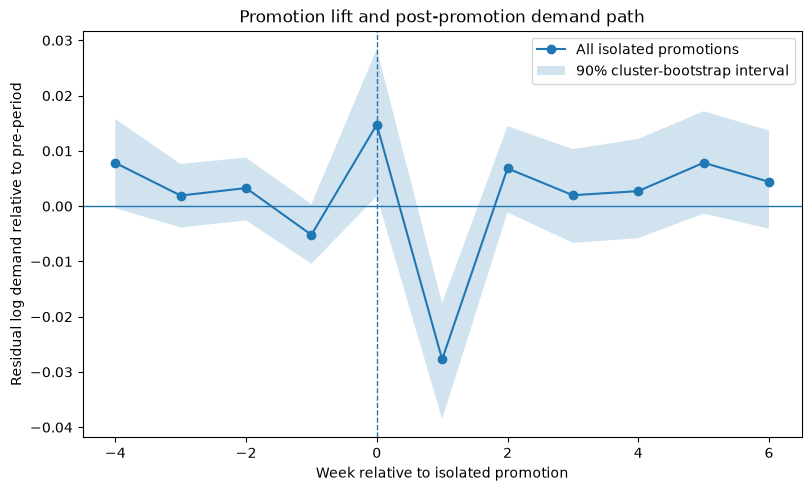

In [21]:
# Pooled promotion-response figure.

# Plot the pooled promotion response and its cluster-bootstrap uncertainty band.
fig, ax = plt.subplots(
    figsize=(8, 4.8),
    constrained_layout=True,
)

ax.plot(
    event_study_table[
        "relative_week"
    ],
    event_study_table[
        "mean_effect"
    ],
    marker="o",
    label="All isolated promotions",
)

ax.fill_between(
    event_study_table[
        "relative_week"
    ],
    event_study_table[
        "ci_lower"
    ],
    event_study_table[
        "ci_upper"
    ],
    alpha=0.20,
    label=(
        "90% cluster-bootstrap interval"
    ),
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.axvline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel(
    "Week relative to isolated promotion"
)

ax.set_ylabel(
    "Residual log demand relative to pre-period"
)

ax.set_title(
    "Promotion lift and post-promotion demand path"
)

ax.legend()


# Save the pooled figure and construct depth-specific paths.

# Save the pooled figure, then plot heterogeneous response paths by measured promotion depth.
fig.savefig(
    EVENT_STUDY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


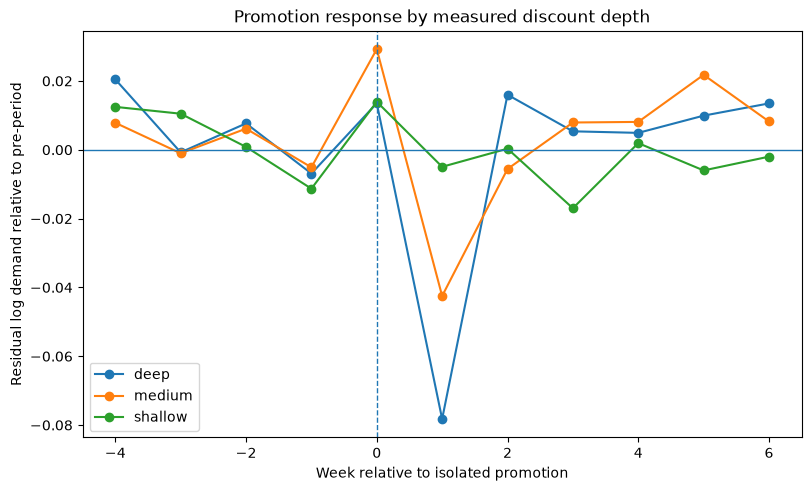

In [22]:
fig, ax = plt.subplots(
    figsize=(8, 4.8),
    constrained_layout=True,
)

for depth_group, group in (
    depth_event_study_table.groupby(
        "depth_group",
        observed=True,
    )
):
    group = group.sort_values(
        "relative_week"
    )
    ax.plot(
        group[
            "relative_week"
        ],
        group[
            "mean_effect"
        ],
        marker="o",
        label=str(depth_group),
    )

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.axvline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel(
    "Week relative to isolated promotion"
)

ax.set_ylabel(
    "Residual log demand relative to pre-period"
)

ax.set_title(
    "Promotion response by measured discount depth"
)

ax.legend()


# Save and display the depth-specific figure.

fig.savefig(DEPTH_EVENT_STUDY_FIGURE_PATH, dpi=300, bbox_inches='tight')
plt.show()


## 6. Save calibration artifacts

Detailed tables remain machine-readable and available to downstream notebooks,
even though they are no longer displayed throughout the calibration workflow.

In [23]:
# Construct summaries and save the main draw and event-study artifacts.

# Assemble compact moment and parameter summaries and save the main calibration artifacts.
moment_summary = (
    bootstrap_moments.describe(
        percentiles=[
            0.05,
            0.50,
            0.95,
        ]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "moment",
        }
    )
)

parameter_summary = (
    parameter_draws[
        [
            "price_elasticity",
            "promotion_lift_log",
            "displacement_strength",
            "inventory_persistence",
            "base_demand",
            "regular_price",
            "unit_cost",
        ]
    ]
    .describe(
        percentiles=[
            0.05,
            0.50,
            0.95,
        ]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "parameter",
        }
    )
)

parameter_draws.to_pickle(
    PARAMETER_OUTPUT_PATH
)

base_parameter_draws.to_pickle(
    BASE_PARAMETER_OUTPUT_PATH
)

event_study_table.to_csv(
    EVENT_STUDY_TABLE_PATH,
    index=False,
)


In [24]:
# Save the remaining reporting tables.

# Save the remaining event-study and summary tables used by later notebooks and the paper.
depth_event_study_table.to_csv(
    DEPTH_EVENT_STUDY_TABLE_PATH,
    index=False,
)

moment_summary.to_csv(
    MOMENT_TABLE_PATH,
    index=False,
)

parameter_summary.to_csv(
    PARAMETER_SUMMARY_PATH,
    index=False,
)


In [25]:
# Record the exact calibration design and parameter mapping.

# Record the exact calibration choices and parameter mapping in a machine-readable configuration artifact.
configuration = {
    "primary_model": PRIMARY_MODEL,
    "calibration_end_week": int(
        CALIBRATION_END_WEEK
    ),
    "evaluation_start_week": int(
        EVALUATION_START_WEEK
    ),
    "event_window": (
        EVENT_WINDOW.tolist()
    ),
    "pre_event_weeks": list(
        PRE_EVENT_WEEKS
    ),
    "post_lags_for_calibration": list(
        POST_LAGS_FOR_CALIBRATION
    ),
    "selected_isolation_gap": list(
        selected_gap
    ),
    "selected_calibration_discount": float(
        selected_calibration_discount
    ),
    "isolated_events": int(
        len(event_summary)
    ),
    "depth_calibration_events": int(
        calibration_event_summary.shape[0]
    ),
    "bootstrap_replications": int(
        BOOTSTRAP_REPLICATIONS
    ),
    "completed_bootstrap_replications": int(
        completed_bootstrap_replications
    ),
    "random_seed": int(
        RANDOM_SEED
    ),
    "parameter_mapping": {
        "demand": (
            "Q0*(1-d)^(-epsilon)*"
            "exp(gamma*1[d>0]-psi*I)"
        ),
        "inventory": (
            "I_next=r*I+d"
        ),
        "promotion_lift": (
            "event0_demand_residual_change-beta_price*event0_price_residual_change"
        ),
        "displacement_strength": (
            "slope_of_week1_dip_on_discount_depth"
        ),
        "persistence": (
            "identified_only_when_week1_and_week2_depth_slopes_are_positive_and_decay_consistent;otherwise_partial_identification"
        ),
    },
    "persistence_partial_id_grid": list(
        PERSISTENCE_PARTIAL_ID_GRID
    ),
    "calibration_role": (
        "reduced_form_moment_calibration_"
        "not_causal_structural_identification"
    ),
}

# Write the machine-readable configuration.

CONFIGURATION_PATH.write_text(json.dumps(configuration, indent=2), encoding='utf-8')

print(
    "Behavioral calibration complete:",
    f"{len(parameter_draws):,} weighted draws, "
    f"{len(event_summary):,} complete events, "
    f"artifacts saved under {CALIBRATION_ARTIFACT_DIR}.",
)


Behavioral calibration complete: 2,762 weighted draws, 3,004 complete events, artifacts saved under C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\calibration.
